# RQ3: Clustering — What Developer Archetypes Emerge from Survey Data?

**Research Question:** What distinct developer archetypes emerge from the joint analysis of technology stack preferences, professional experience, organizational context, and AI tool adoption patterns — and how reliably do unsupervised clustering algorithms identify and separate these profiles?

**Task:** Unsupervised Clustering  
**Features:** YearsCode, WorkExp, OrgSize, EdLevel, RemoteWork, AI usage + top-15 language multi-hot  
**Methods:** K-Means, Agglomerative Hierarchical, DBSCAN  
**Dataset:** Stack Overflow Annual Developer Survey 2025

In [46]:
import os
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#795548', '#607D8B']
sns.set_palette(PALETTE)
RANDOM_STATE = 42
OUTPUT_DIR = '/kaggle/working/'

def save_figure(fig, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    fig.savefig(path, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close(fig)
    print(f'Saved figure: {path}')

def save_table(df, filename):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print(f'Saved table:  {path}')

def multihot_encode(series, top_n=15, prefix=''):
    all_vals = []
    for v in series.dropna():
        if v != 'NA':
            all_vals.extend([x.strip() for x in v.split(';')])
    top_vals = [v for v, _ in Counter(all_vals).most_common(top_n)]
    result = pd.DataFrame(index=series.index)
    for val in top_vals:
        col = f"{prefix}{val.replace(' ', '_').replace(',', '').replace('/', '_')}"
        result[col] = series.apply(
            lambda x: 1 if (isinstance(x, str) and x != 'NA' and val in x.split(';')) else 0
        )
    return result, top_vals

ORGSIZE_MAP = {
    'Just me - I am a freelancer, sole proprietor, etc.': 1,
    'Less than 20 employees': 2, '20 to 99 employees': 3,
    '100 to 499 employees': 4, '500 to 999 employees': 5,
    '1,000 to 4,999 employees': 6, '5,000 to 9,999 employees': 7,
    '10,000 or more employees': 8
}

EDLEVEL_MAP = {
    'Primary/elementary school': 0,
    'Secondary school (e.g. American high school)': 1,
    'Some college/university study without earning a degree': 2,
    'Associate degree (A.A., A.S., etc.)': 3,
    'Bachelor’s degree (B.A., B.S., B.Eng., etc.)': 3,
    "Bachelor's degree (B.A., B.S., B.Eng., etc.)": 3,
    'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 4,
    "Master's degree (M.A., M.S., M.Eng., MBA, etc.)": 4,
    'Professional degree (JD, MD, Ph.D, Ed.D, etc.)': 5,
    'Something else': 2
}

REMOTEWORK_MAP = {
    'Remote': 2,
    'Your choice (very flexible or no formal remote work policy)': 2,
    'Hybrid (some in-person, leans heavy to flexibility)': 1,
    'Hybrid (some remote, leans heavy to in-person)': 1,
    'In-person': 0
}

print('Imports OK')

Imports OK


## 1. Data Loading

In [47]:
import glob
matches = glob.glob('/kaggle/input/**/survey_results_public.csv', recursive=True)
if not matches:
    raise FileNotFoundError('survey_results_public.csv not found under /kaggle/input/')
FILE_PATH = matches[0]
print('Using:', FILE_PATH)

df = pd.read_csv(FILE_PATH, encoding='utf-8-sig')
print(f'Shape: {df.shape}')

Using: /kaggle/input/datasets/edoardogalli/stack-overflow-annual-developer-survey-2025/survey_results_public.csv
Shape: (49123, 170)


## 2. Feature Engineering

In [48]:
# Filter to professional developers
df_dev = df[df['MainBranch'] == 'I am a developer by profession'].copy()
print(f'Professional developers: {df_dev.shape[0]}')

# Numeric conversions
df_dev['YearsCode']    = pd.to_numeric(df_dev['YearsCode'], errors='coerce')
df_dev['WorkExp']      = pd.to_numeric(df_dev['WorkExp'],   errors='coerce')
df_dev['OrgSize_num']  = df_dev['OrgSize'].map(ORGSIZE_MAP)
df_dev['EdLevel_num']  = df_dev['EdLevel'].map(EDLEVEL_MAP)
df_dev['RemoteWork_num'] = df_dev['RemoteWork'].map(REMOTEWORK_MAP)

# AI_User binary
df_dev['AI_User'] = df_dev['AISelect'].apply(
    lambda x: 1 if isinstance(x, str) and x.startswith('Yes') else
              (0 if isinstance(x, str) and 'No' in x else np.nan)
)

# Multi-hot: top 15 languages
lang_mh, lang_top = multihot_encode(df_dev['LanguageHaveWorkedWith'], top_n=15, prefix='lang_')
df_dev = pd.concat([df_dev.reset_index(drop=True), lang_mh.reset_index(drop=True)], axis=1)
LANG_COLS = list(lang_mh.columns)

CLUSTER_FEATURES = ['YearsCode', 'WorkExp', 'OrgSize_num', 'EdLevel_num',
                    'RemoteWork_num', 'AI_User'] + LANG_COLS

X_raw = df_dev[CLUSTER_FEATURES].copy()

# Drop rows with >50% missing
threshold = len(CLUSTER_FEATURES) * 0.5
X_raw = X_raw[X_raw.isnull().sum(axis=1) <= threshold]
print(f'Clustering input shape: {X_raw.shape}')

Professional developers: 37418
Clustering input shape: (37418, 21)


## 3. Preprocessing & PCA

In [49]:
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_imputed = imputer.fit_transform(X_raw)
X_scaled  = scaler.fit_transform(X_imputed)

# Full PCA to find components explaining 90% variance
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_scaled)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components_90 = np.argmax(cumvar >= 0.90) + 1
print(f'Components for 90% variance: {n_components_90}')

# PCA for clustering
pca_cluster = PCA(n_components=n_components_90, random_state=RANDOM_STATE)
X_pca = pca_cluster.fit_transform(X_scaled)

# PCA 2D for visualization
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca_2d.fit_transform(X_scaled)
print(f'2D PCA explains {pca_2d.explained_variance_ratio_.sum()*100:.1f}% variance')

Components for 90% variance: 16
2D PCA explains 30.0% variance


## 4. K-Means: Optimal K Selection

In [50]:
K_range = range(2, 13)
inertias   = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca, labels, sample_size=5000, random_state=RANDOM_STATE))
    print(f'K={k}: inertia={km.inertia_:.0f}, silhouette={sil_scores[-1]:.4f}')

OPTIMAL_K = K_range[np.argmax(sil_scores)]
print(f'\nOptimal K (max silhouette): {OPTIMAL_K}')

K=2: inertia=598312, silhouette=0.2055
K=3: inertia=549492, silhouette=0.2096
K=4: inertia=519413, silhouette=0.2169
K=5: inertia=494202, silhouette=0.2108
K=6: inertia=471925, silhouette=0.2034
K=7: inertia=452958, silhouette=0.1911
K=8: inertia=436870, silhouette=0.1905
K=9: inertia=424551, silhouette=0.1880
K=10: inertia=414696, silhouette=0.1914
K=11: inertia=405822, silhouette=0.1850
K=12: inertia=398491, silhouette=0.1537

Optimal K (max silhouette): 4


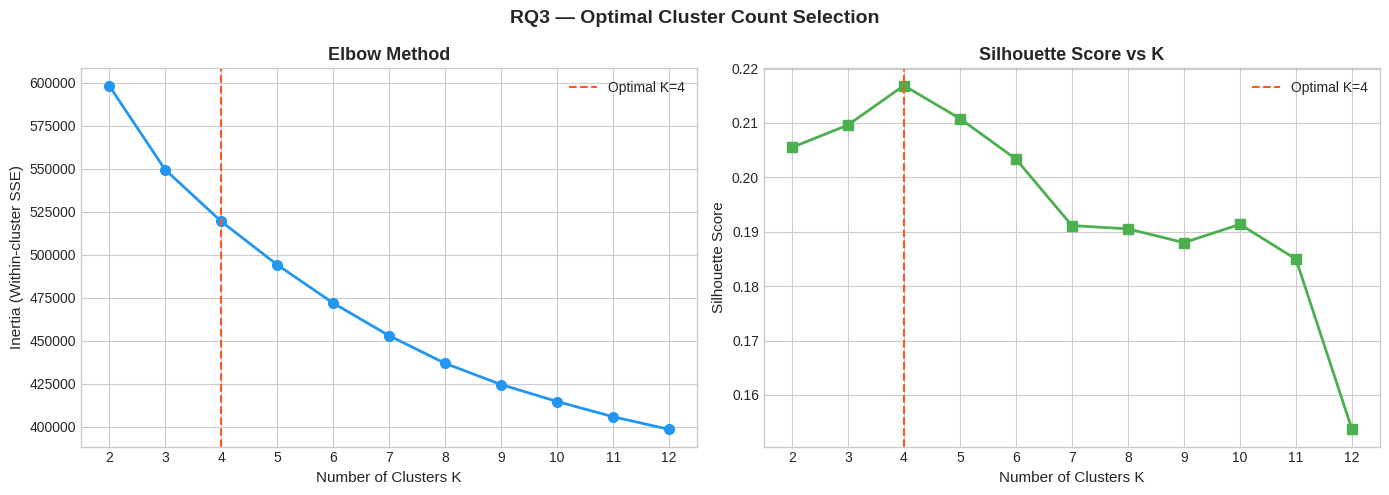

Saved figure: /kaggle/working/rq3_optimal_k_selection.pdf


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'o-', color=PALETTE[0], linewidth=2, markersize=7)
axes[0].axvline(OPTIMAL_K, color=PALETTE[1], linestyle='--', linewidth=1.5, label=f'Optimal K={OPTIMAL_K}')
axes[0].set_xlabel('Number of Clusters K', fontsize=11)
axes[0].set_ylabel('Inertia (Within-cluster SSE)', fontsize=11)
axes[0].set_title('Elbow Method', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xticks(list(K_range))

axes[1].plot(list(K_range), sil_scores, 's-', color=PALETTE[2], linewidth=2, markersize=7)
axes[1].axvline(OPTIMAL_K, color=PALETTE[1], linestyle='--', linewidth=1.5, label=f'Optimal K={OPTIMAL_K}')
axes[1].set_xlabel('Number of Clusters K', fontsize=11)
axes[1].set_ylabel('Silhouette Score', fontsize=11)
axes[1].set_title('Silhouette Score vs K', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].set_xticks(list(K_range))

fig.suptitle('RQ3 — Optimal Cluster Count Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
save_figure(fig, 'rq3_optimal_k_selection.pdf')
plt.show()

## 5. Clustering Methods

In [52]:
# K-Means (optimal K)
km_final = KMeans(n_clusters=OPTIMAL_K, n_init=20, random_state=RANDOM_STATE)
km_labels = km_final.fit_predict(X_pca)

# Agglomerative
agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg.fit_predict(X_pca)

# DBSCAN with eps from 5-NN distances
nn5 = NearestNeighbors(n_neighbors=5, n_jobs=-1)
nn5.fit(X_pca)
dists, _ = nn5.kneighbors(X_pca)
eps_val = np.percentile(dists[:, -1], 95)
print(f'DBSCAN eps (95th percentile 5-NN): {eps_val:.4f}')
dbscan = DBSCAN(eps=eps_val, min_samples=5, n_jobs=-1)
db_labels = dbscan.fit_predict(X_pca)
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db    = (db_labels == -1).sum()
print(f'DBSCAN clusters: {n_clusters_db}, noise points: {n_noise_db}')

# Metrics
def compute_metrics(X, labels, name):
    mask = labels != -1
    if mask.sum() < 2 or len(set(labels[mask])) < 2:
        return {'Method': name, 'Silhouette': np.nan, 'Davies_Bouldin': np.nan, 'Calinski_Harabasz': np.nan}
    sil = silhouette_score(X[mask], labels[mask], sample_size=5000, random_state=RANDOM_STATE)
    db  = davies_bouldin_score(X[mask], labels[mask])
    ch  = calinski_harabasz_score(X[mask], labels[mask])
    return {'Method': name, 'Silhouette': round(sil, 4),
            'Davies_Bouldin': round(db, 4), 'Calinski_Harabasz': round(ch, 2)}

metrics_list = [
    compute_metrics(X_pca, km_labels,  f'K-Means (K={OPTIMAL_K})'),
    compute_metrics(X_pca, agg_labels, f'Agglomerative (K={OPTIMAL_K})'),
    compute_metrics(X_pca, db_labels,  f'DBSCAN (eps={eps_val:.3f})')
]
metrics_df = pd.DataFrame(metrics_list)
print(metrics_df)

DBSCAN eps (95th percentile 5-NN): 3.2140
DBSCAN clusters: 11, noise points: 824
                Method  Silhouette  Davies_Bouldin  Calinski_Harabasz
0        K-Means (K=4)      0.2169          2.2095            4887.89
1  Agglomerative (K=4)      0.1735          2.5452            4172.47
2   DBSCAN (eps=3.214)      0.1917          1.5902             541.50


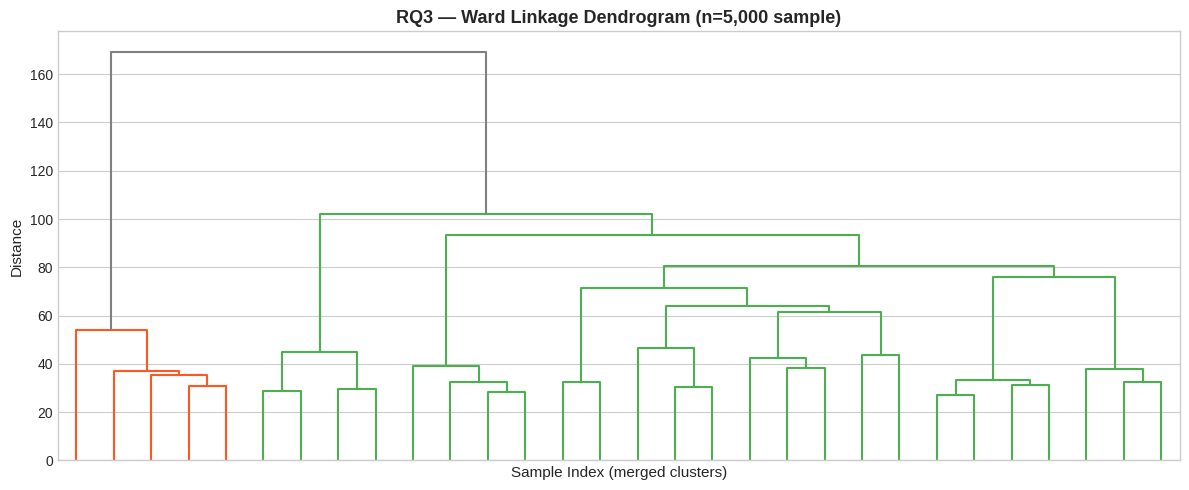

Saved figure: /kaggle/working/rq3_dendrogram.pdf


In [53]:
# Dendrogram on 5,000-row sample
np.random.seed(RANDOM_STATE)
sample_idx = np.random.choice(len(X_pca), min(5000, len(X_pca)), replace=False)
X_sample = X_pca[sample_idx]

Z = linkage(X_sample, method='ward')

fig, ax = plt.subplots(figsize=(12, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, leaf_rotation=45,
           color_threshold=None, above_threshold_color='gray', no_labels=True)
ax.set_title(f'RQ3 — Ward Linkage Dendrogram (n=5,000 sample)', fontsize=13, fontweight='bold')
ax.set_xlabel('Sample Index (merged clusters)', fontsize=11)
ax.set_ylabel('Distance', fontsize=11)
plt.tight_layout()
save_figure(fig, 'rq3_dendrogram.pdf')
plt.show()

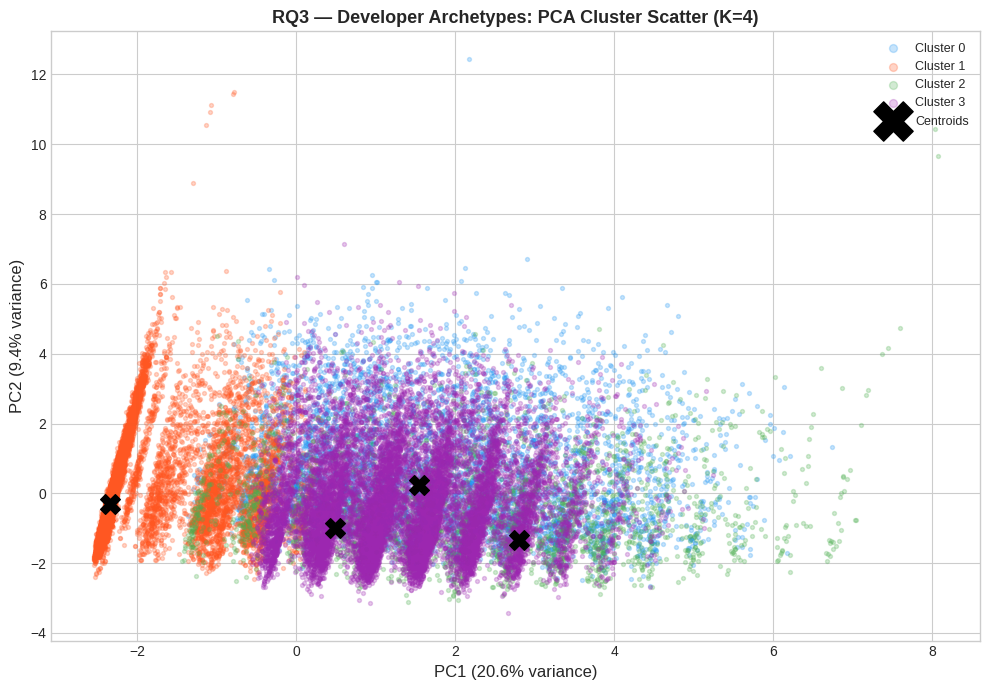

Saved figure: /kaggle/working/rq3_pca_cluster_scatter.pdf


In [54]:
# PCA 2D scatter colored by K-Means clusters
centroids_2d = pca_2d.transform(scaler.transform(imputer.transform(
    np.array([X_raw.iloc[km_labels == c].median().fillna(0) for c in range(OPTIMAL_K)])
)))

fig, ax = plt.subplots(figsize=(10, 7))
for c in range(OPTIMAL_K):
    mask = km_labels == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], alpha=0.25, s=8,
               color=PALETTE[c % len(PALETTE)], label=f'Cluster {c}')
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1], marker='X', s=200,
           c='black', zorder=5, label='Centroids')
pc1_var = pca_2d.explained_variance_ratio_[0] * 100
pc2_var = pca_2d.explained_variance_ratio_[1] * 100
ax.set_xlabel(f'PC1 ({pc1_var:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pc2_var:.1f}% variance)', fontsize=12)
ax.set_title(f'RQ3 — Developer Archetypes: PCA Cluster Scatter (K={OPTIMAL_K})', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, markerscale=2)
plt.tight_layout()
save_figure(fig, 'rq3_pca_cluster_scatter.pdf')
plt.show()

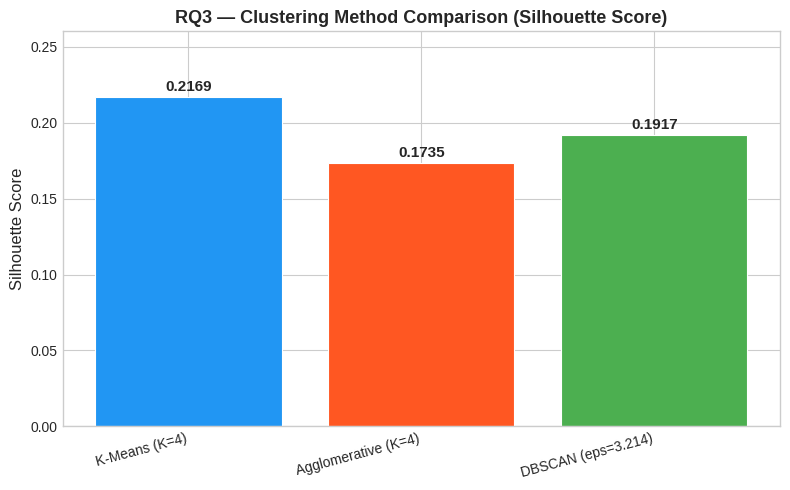

Saved figure: /kaggle/working/rq3_clustering_method_comparison.pdf


In [55]:
# Clustering method comparison
fig, ax = plt.subplots(figsize=(8, 5))
valid = metrics_df.dropna(subset=['Silhouette'])
bars = ax.bar(valid['Method'], valid['Silhouette'], color=PALETTE[:len(valid)],
              edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, valid['Silhouette']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('RQ3 — Clustering Method Comparison (Silhouette Score)', fontsize=13, fontweight='bold')
ax.set_ylim(0, valid['Silhouette'].max() * 1.2)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
save_figure(fig, 'rq3_clustering_method_comparison.pdf')
plt.show()

## 6. Cluster Profiles

In [56]:
X_raw_reset = X_raw.copy().reset_index(drop=True)
X_raw_reset = X_raw_reset.iloc[:len(km_labels)]
X_raw_reset['KMeans_Cluster'] = km_labels

# Add DevType for dominant type per cluster
df_dev_reset = df_dev.reset_index(drop=True)
df_dev_aligned = df_dev_reset.iloc[:len(X_raw)].reset_index(drop=True).iloc[:len(km_labels)]
X_raw_reset['DevType'] = df_dev_aligned['DevType'].values

def dominant_devtype(series):
    all_vals = []
    for v in series.dropna():
        if isinstance(v, str) and v != 'NA':
            all_vals.extend([x.strip() for x in v.split(';')])
    if not all_vals:
        return 'Unknown'
    return Counter(all_vals).most_common(1)[0][0]

profile_rows = []
for c in range(OPTIMAL_K):
    sub = X_raw_reset[X_raw_reset['KMeans_Cluster'] == c]
    row = {'Cluster': c}
    for col in ['YearsCode', 'WorkExp', 'OrgSize_num', 'EdLevel_num', 'AI_User', 'RemoteWork_num']:
        row[f'{col}_mean'] = round(sub[col].mean(), 3) if col in sub.columns else np.nan
    top5_langs = sorted(LANG_COLS, key=lambda l: sub[l].mean() if l in sub.columns else 0, reverse=True)[:5]
    for lc in top5_langs:
        row[f'{lc}_rate'] = round(sub[lc].mean(), 3) if lc in sub.columns else np.nan
    row['Count'] = len(sub)
    row['Pct']   = round(len(sub) / len(X_raw_reset) * 100, 2)
    row['Dominant_DevType'] = dominant_devtype(sub['DevType'])
    profile_rows.append(row)

profile_df = pd.DataFrame(profile_rows)
save_table(profile_df, 'rq3_cluster_profiles.csv')
profile_df

Saved table:  /kaggle/working/rq3_cluster_profiles.csv


,Cluster,YearsCode_mean,WorkExp_mean,OrgSize_num_mean,EdLevel_num_mean,AI_User_mean,RemoteWork_num_mean,lang_Python_rate,lang_C++_rate,lang_C_rate,...,lang_JavaScript_rate,Count,Pct,Dominant_DevType,lang_SQL_rate,lang_C#_rate,lang_Java_rate,lang_Kotlin_rate,lang_HTML_CSS_rate,lang_TypeScript_rate
0,0,19.897,14.487,4.603,3.402,0.671,1.049,0.793,0.785,0.757,...,0.560,4887,13.06,"Developer, full-stack",NaN,NaN,NaN,NaN,NaN,NaN
1,1,15.990,11.905,4.394,3.252,0.834,1.175,0.087,NaN,NaN,...,NaN,16559,44.25,"Developer, full-stack",0.070,0.045,0.041,NaN,NaN,NaN
2,2,16.958,12.471,4.421,3.248,0.855,1.201,NaN,NaN,NaN,...,0.717,2768,7.40,"Developer, full-stack",0.647,NaN,0.699,1.0,0.627,NaN
3,3,17.779,13.613,4.191,3.184,0.837,1.300,0.496,NaN,NaN,...,0.886,13204,35.29,"Developer, full-stack",0.747,NaN,NaN,NaN,0.832,0.64


## 7. Conclusions

In [57]:
best_method = metrics_df.loc[metrics_df['Silhouette'].idxmax()]
print('=' * 60)
print('RQ3 CONCLUSION')
print('=' * 60)
print(f'Optimal K (K-Means):    {OPTIMAL_K}')
print(f'Best method:            {best_method["Method"]}')
print(f'  Silhouette Score:     {best_method["Silhouette"]}')
print(f'  Davies-Bouldin:       {best_method["Davies_Bouldin"]}')
print()
print('Cluster sizes:')
for _, row in profile_df.iterrows():
    print(f'  Cluster {int(row["Cluster"])}: {int(row["Count"]):,} developers ({row["Pct"]}%) '
          f'— dominant role: {row["Dominant_DevType"]}')
print()
print('Output files saved to /kaggle/working/:')
print('  rq3_optimal_k_selection.pdf')
print('  rq3_dendrogram.pdf')
print('  rq3_pca_cluster_scatter.pdf')
print('  rq3_clustering_method_comparison.pdf')
print('  rq3_cluster_profiles.csv')

RQ3 CONCLUSION
Optimal K (K-Means):    4
Best method:            K-Means (K=4)
  Silhouette Score:     0.2169
  Davies-Bouldin:       2.2095

Cluster sizes:
  Cluster 0: 4,887 developers (13.06%) — dominant role: Developer, full-stack
  Cluster 1: 16,559 developers (44.25%) — dominant role: Developer, full-stack
  Cluster 2: 2,768 developers (7.4%) — dominant role: Developer, full-stack
  Cluster 3: 13,204 developers (35.29%) — dominant role: Developer, full-stack

Output files saved to /kaggle/working/:
  rq3_optimal_k_selection.pdf
  rq3_dendrogram.pdf
  rq3_pca_cluster_scatter.pdf
  rq3_clustering_method_comparison.pdf
  rq3_cluster_profiles.csv
